# Задача 3. ML / DL и аномалии

- **ML (mlforecast):** LightGBM, RandomForest, Ridge + lag/date features
- **DL (neuralforecast):** NHITS, NBEATS, LSTM
- **Аномалии:** IQR, STL+Z-score, Isolation Forest

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from lightgbm import LGBMRegressor
from mlforecast import MLForecast
from mlforecast.lag_transforms import ExpandingMean, RollingMean
from mlforecast.target_transforms import Differences
from neuralforecast import NeuralForecast
from neuralforecast.models import LSTM, NBEATS, NHITS
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge

from src.anomaly import iqr_anomaly_scores, isolation_forest_anomalies, stl_zscore_anomalies
from src.config import FORECAST_HORIZON, SEASON
from src.metrics import evaluate, metrics_table
from src.stats import (
    cv_by_window,
    cv_summary,
    plot_cv_rmse_by_window,
    plot_residual_diagnostics,
    with_cv_residuals,
    with_residuals,
)

H = FORECAST_HORIZON
CV_H = 24
N_WINDOWS = 5
DL_N_WINDOWS = 3
CV_STEP = 24

In [2]:
train_df = pd.read_parquet('__output__/train.parquet')
test_df = pd.read_parquet('__output__/test.parquet')

In [3]:
def df2data(df: pd.DataFrame):
    return pd.DataFrame({
        'unique_id': df['unique_id'].copy(),
        'ds': df.index.values.copy(),
        'y': df['AC_POWER'].copy(),
        'AMBIENT_TEMPERATURE': df['AMBIENT_TEMPERATURE'].copy(),
        'MODULE_TEMPERATURE': df['MODULE_TEMPERATURE'].copy(),
        'IRRADIATION': df['IRRADIATION'].copy(),
    })

In [4]:
train_data = df2data(train_df)
test_data = df2data(test_df)

## 3 метода выявления аномалий

Сравниваем **IQR** (baseline по квантилям), **STL + Z-score** (остатки после декомпозиции, period=24) и **Isolation Forest** (многомерные выбросы по power + weather). Анализ выполняется на train-части Plant 1.

,method,n_anomalies,share_pct
0,IQR,0,0.00
1,STL+Z-score,24,3.13
2,Isolation Forest,16,2.09


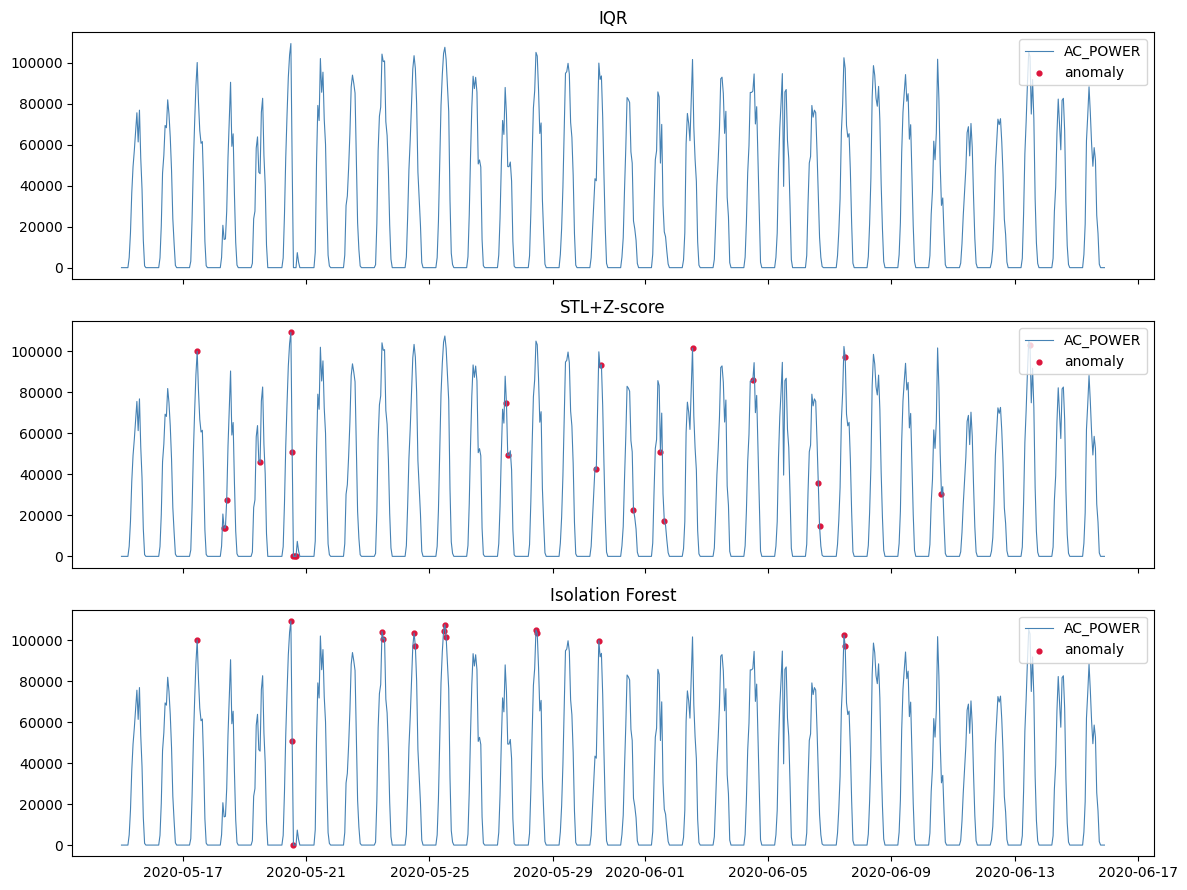

In [5]:
plant1 = train_df[train_df['unique_id'] == '1'].copy()
power = plant1['AC_POWER']

iqr_flags = iqr_anomaly_scores(power, k=1.5)
stl_res = stl_zscore_anomalies(power, period=SEASON, z_threshold=3.0)
iso_res = isolation_forest_anomalies(
    plant1[['AC_POWER', 'IRRADIATION', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE']],
    contamination=0.02,
)

anomaly_df = pd.DataFrame(
    {
        'AC_POWER': power,
        'IQR': iqr_flags,
        'STL+Z-score': stl_res['is_anomaly'],
        'IsolationForest': iso_res['is_anomaly'],
    },
    index=power.index,
)

anomaly_summary = pd.DataFrame(
    {
        'method': ['IQR', 'STL+Z-score', 'Isolation Forest'],
        'n_anomalies': [
            anomaly_df['IQR'].sum(),
            anomaly_df['STL+Z-score'].sum(),
            anomaly_df['IsolationForest'].sum(),
        ],
    }
)
anomaly_summary['share_pct'] = (
    100 * anomaly_summary['n_anomalies'] / len(anomaly_df)
).round(2)

display(anomaly_summary)

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
for ax, (method, col) in zip(
    axes,
    [('IQR', 'IQR'), ('STL+Z-score', 'STL+Z-score'), ('Isolation Forest', 'IsolationForest')],
):
    ax.plot(anomaly_df.index, anomaly_df['AC_POWER'], color='steelblue', linewidth=0.8, label='AC_POWER')
    mask = anomaly_df[col]
    ax.scatter(
        anomaly_df.index[mask],
        anomaly_df.loc[mask, 'AC_POWER'],
        color='crimson',
        s=12,
        label='anomaly',
    )
    ax.set_title(method)
    ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

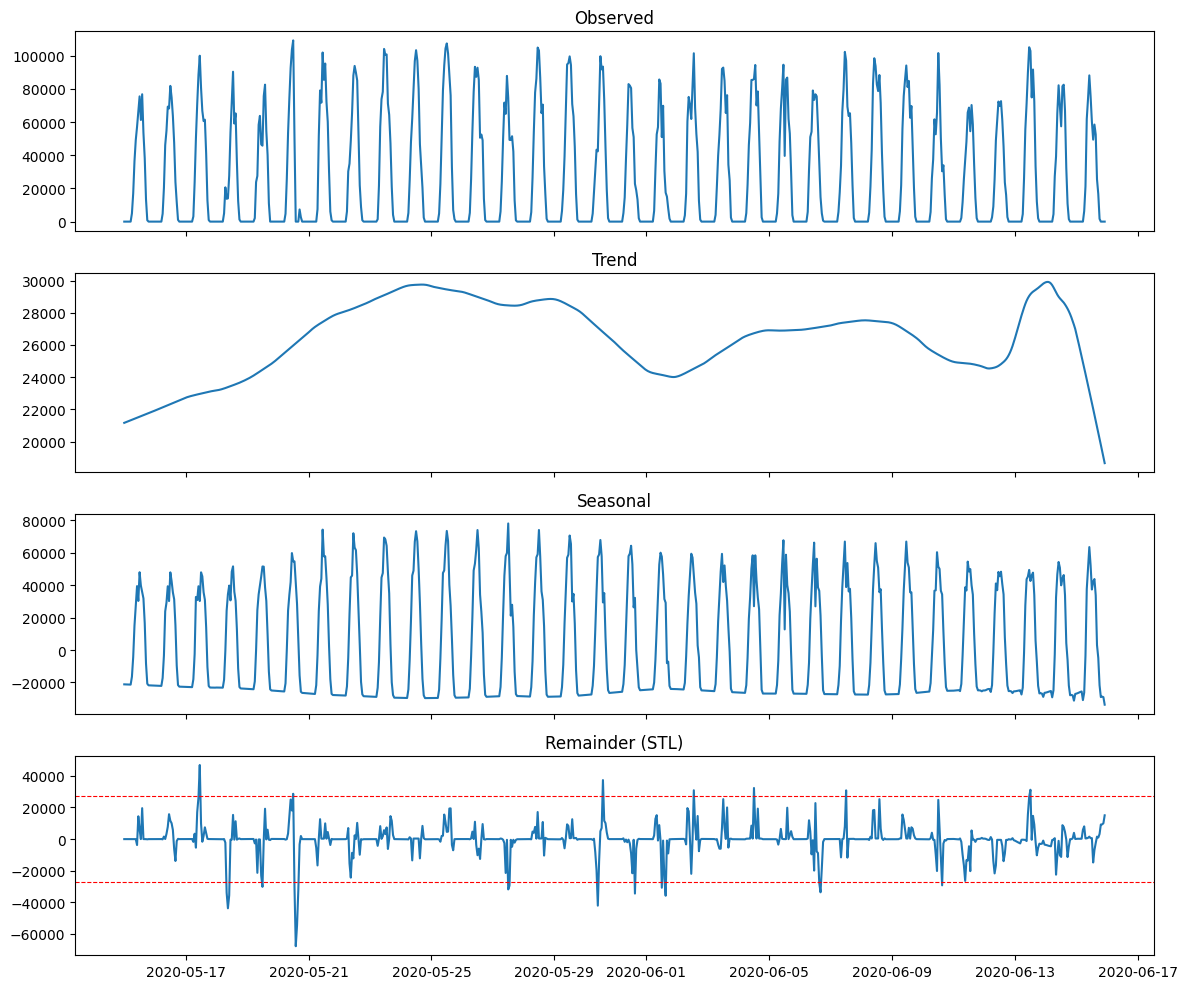

IQR vs STL+Z-score:


STL+Z-score,False,True
IQR,,
False,743,24


In [23]:
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
axes[0].plot(stl_res.index, stl_res['observed'])
axes[0].set_title('Observed')
axes[1].plot(stl_res.index, stl_res['trend'])
axes[1].set_title('Trend')
axes[2].plot(stl_res.index, stl_res['seasonal'])
axes[2].set_title('Seasonal')
axes[3].plot(stl_res.index, stl_res['remainder'])
axes[3].axhline(3 * stl_res['remainder'].std(ddof=0), color='r', linestyle='--', linewidth=0.8)
axes[3].axhline(-3 * stl_res['remainder'].std(ddof=0), color='r', linestyle='--', linewidth=0.8)
axes[3].set_title('Remainder (STL)')
plt.tight_layout()
plt.show()

overlap = pd.crosstab(anomaly_df['IQR'], anomaly_df['STL+Z-score'])
print('IQR vs STL+Z-score:')
display(overlap)

## ML — mlforecast (3 модели)

In [7]:
ml_models = [
    LGBMRegressor(n_estimators=300, learning_rate=0.05, random_state=42),
    RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    Ridge(alpha=1.0)
]

mlf = MLForecast(
    models=ml_models,
    freq='h',
    lags=[1, 2, 6, 12, 24],
    lag_transforms={
        1: [ExpandingMean()],
        24: [RollingMean(window_size=3)],
    },
    date_features=['hour', 'dayofweek'],
    target_transforms=[Differences([24])]
)

In [8]:
mlf.fit(train_data, static_features=[])

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000595 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2581
[LightGBM] [Info] Number of data points in the train set: 1434, number of used features: 12
[LightGBM] [Info] Start training from score -89.126420


MLForecast(models=[LGBMRegressor, RandomForestRegressor, Ridge], freq=h, lag_features=['lag1', 'lag2', 'lag6', 'lag12', 'lag24', 'expanding_mean_lag1', 'rolling_mean_lag24_window_size3'], date_features=['hour', 'dayofweek'], num_threads=1)

In [9]:
ml_forecasts = mlf.predict(h=H, X_df=test_data)

## DL — neuralforecast (3 модели)

In [10]:
dl_models = [
    NHITS(h=H, input_size=72, max_steps=200),
    NBEATS(h=H, input_size=72, max_steps=200),
    LSTM(h=H, input_size=72, max_steps=200),
]

dlf = NeuralForecast(models=dl_models, freq='h')

Seed set to 1
Seed set to 1
Seed set to 1


In [11]:
dlf.fit(train_data)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
You are using a CUDA device ('NVIDIA GeForce RTX 3050 Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | blocks       | ModuleList    | 2.6 M  | train
-------------------------------------------------------
2.6 M     Trainable params
0         Non-trainable params
2.6 M     Total params
10.372    Total estimated model params size (MB)
34        

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

d:\GitProjects\TSA\.venv\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=200` reached.


In [12]:
dl_forecasts = dlf.predict(h=H, futr_df=test_data)

d:\GitProjects\TSA\.venv\Lib\site-packages\neuralforecast\core.py:1067: UserWarning: Dropped 2 unused rows from `futr_df`.
  warnings.warn(f"Dropped {dropped_rows:,} unused rows from `futr_df`.")
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
d:\GitProjects\TSA\.venv\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Predicting: |          | 0/? [00:00<?, ?it/s]

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
d:\GitProjects\TSA\.venv\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Predicting: |          | 0/? [00:00<?, ?it/s]

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

# Test

In [13]:
def print_metrics(
    data: pd.DataFrame,
    forecast: pd.DataFrame,
    models: list[str]
):
    data = data.merge(
        forecast,
        on=[
            'unique_id',
            'ds'
        ]
    )

    eval_rows = []
    for m_name in models:

        metrics = evaluate(data['y'], data[m_name])
        metrics['model'] = m_name
        eval_rows.append(metrics)

    results_auto = metrics_table(eval_rows)

    return results_auto

In [14]:
# ML

print_metrics(
    test_data,
    ml_forecasts,
    list(mlf.models.keys())
)

,MAE,RMSE,MAPE,sMAPE
model,,,,
Ridge,6577.214514,9493.734833,1.646395e+11,113.640661
RandomForestRegressor,5618.764537,10850.931698,2.767376e+08,27.964519
LGBMRegressor,7105.143619,12329.116548,2.433502e+10,123.547698


In [15]:
# DL

print_metrics(
    test_data,
    dl_forecasts,
    [str(m) for m in dlf.models]
)

,MAE,RMSE,MAPE,sMAPE
model,,,,
NHITS,5511.730470,9963.547774,8.406318e+09,109.009168
NBEATS,5998.559626,10578.470750,2.338523e+10,110.549494
LSTM,5759.210564,10654.635847,4.771823e+09,111.536337


In [16]:
def plot_forecast(
    data: pd.DataFrame,
    forecast: pd.DataFrame,
    models: list[str]
):
    data = data.merge(
        forecast,
        on=[
            'unique_id',
            'ds'
        ]
    )

    fig, axes = plt.subplots(len(models), 1, figsize=(10, 2*len(models)))

    for ax, m_name in zip(axes, models):
        ax.plot(
            data['ds'],
            data['y'],
            label='True'
        )

        ax.plot(
            forecast['ds'],
            forecast[m_name],
            label='Predict'
        )

        ax.legend()
        ax.set_title(f'Model - {m_name}')

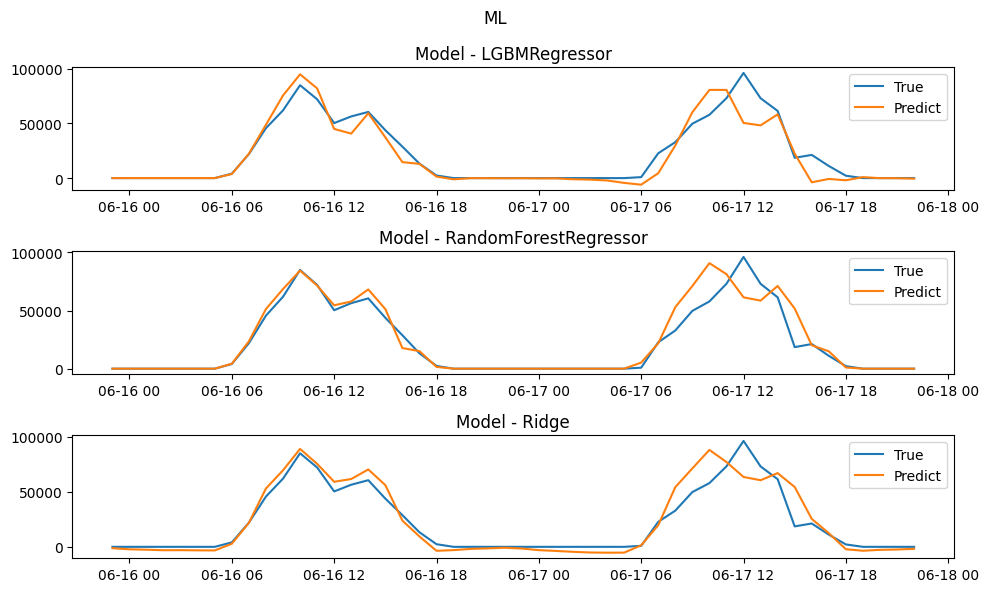

In [17]:
plot_forecast(
    test_data[test_data['unique_id'] == '1'],
    ml_forecasts[ml_forecasts['unique_id'] == '1'],
    list(mlf.models.keys())
)

plt.suptitle('ML')

plt.tight_layout()
plt.show()

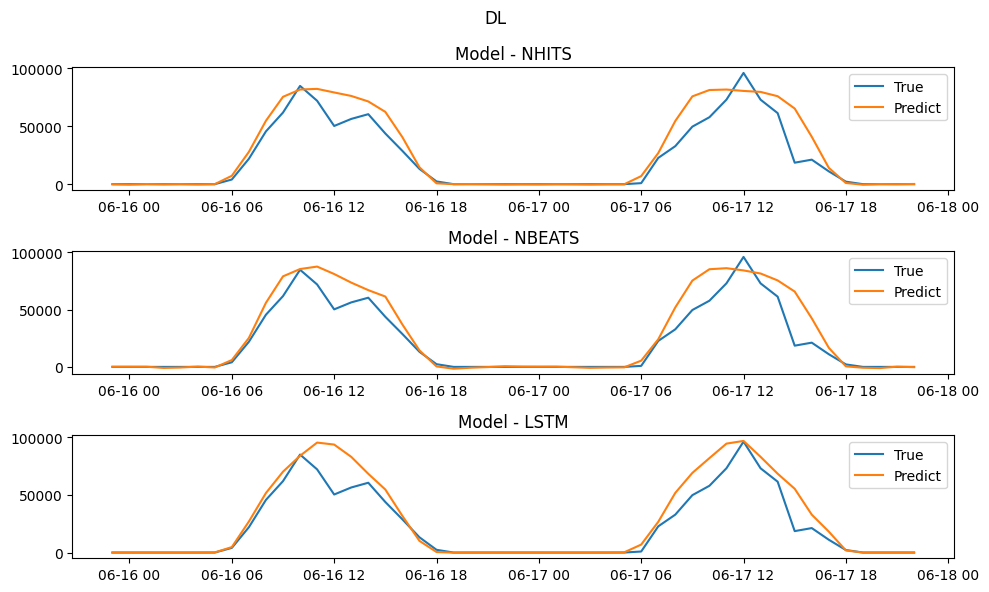

In [18]:
plot_forecast(
    test_data[test_data['unique_id'] == '1'],
    dl_forecasts[dl_forecasts['unique_id'] == '1'],
    [str(m) for m in dlf.models]
)

plt.suptitle('DL')

plt.tight_layout()
plt.show()

## Backtest (ML & DL)

Rolling cross-validation: **h=24 ч**, шаг **24 ч**. ML — 5 окон; DL — 3 окна (медленнее из-за обучения нейросетей).

ML cross-validation: h=24, n_windows=5, step=24
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000291 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1491
[LightGBM] [Info] Number of data points in the train set: 597, number of used features: 12
[LightGBM] [Info] Start training from score -4.057496
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] 

,MAE,RMSE,MAPE,sMAPE
model,,,,
RandomForestRegressor,5892.156946,10798.055135,6.433645e+08,27.170441
Ridge,6718.131700,10976.902477,7.168084e+10,111.706529
LGBMRegressor,7283.726402,11201.357321,6.501120e+10,121.032676


model,LGBMRegressor,RandomForestRegressor,Ridge
cutoff,,,
2020-06-10 22:00:00,12145.79,12490.44,12036.78
2020-06-11 22:00:00,11520.69,5449.89,4747.69
2020-06-12 22:00:00,12322.51,13060.65,10700.47
2020-06-13 22:00:00,11306.22,10628.76,14411.44
2020-06-14 22:00:00,8211.62,10664.26,10622.97


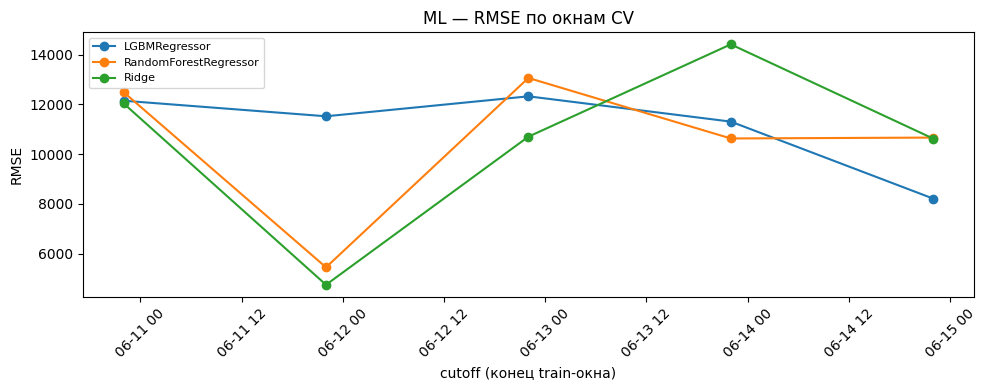

Лучшая ML-модель по backtest: RandomForestRegressor


In [19]:
cv_data = train_data[train_data['unique_id'] == '1']

mlf_cv = MLForecast(
    models=ml_models,
    freq='h',
    lags=[1, 2, 6, 12, 24],
    lag_transforms={
        1: [ExpandingMean()],
        24: [RollingMean(window_size=3)],
    },
    date_features=['hour', 'dayofweek'],
    target_transforms=[Differences([24])],
)

print(f'ML cross-validation: h={CV_H}, n_windows={N_WINDOWS}, step={CV_STEP}')
ml_cv = mlf_cv.cross_validation(
    df=cv_data,
    n_windows=N_WINDOWS,
    h=CV_H,
    step_size=CV_STEP,
    static_features=[],
)
ml_cv_names = list(mlf_cv.models.keys())

ml_cv_overall = cv_summary(ml_cv, ml_cv_names)
display(ml_cv_overall)

ml_cv_window = cv_by_window(ml_cv, ml_cv_names)
display(ml_cv_window.pivot(index='cutoff', columns='model', values='RMSE').round(2))
plot_cv_rmse_by_window(ml_cv_window, ml_cv_names, title='ML — RMSE по окнам CV')

best_ml_cv = ml_cv_overall.index[0]
print(f'Лучшая ML-модель по backtest: {best_ml_cv}')

Seed set to 1
Seed set to 1
Seed set to 1


DL cross-validation: h=24, n_windows=3, step=24


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | blocks       | ModuleList    | 2.6 M  | train
-------------------------------------------------------
2.6 M     Trainable params
0         Non-trainable params
2.6 M     Total params
10.286    Total estimated model params size (MB)
34        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

d:\GitProjects\TSA\.venv\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


...

Predicting: |          | 0/? [00:00<?, ?it/s]

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

,MAE,RMSE,MAPE,sMAPE
model,,,,
NBEATS,7749.094983,13433.275298,2.869416e+10,111.993385
NHITS,8050.538805,14340.596345,1.546744e+10,108.217378
LSTM,7612.045201,14461.880257,3.040199e+09,109.522762


model,LSTM,NBEATS,NHITS
cutoff,,,
2020-06-12 22:00:00,19743.68,15332.39,16258.75
2020-06-13 22:00:00,8483.18,11195.75,13182.86
2020-06-14 22:00:00,12870.92,13451.09,13372.49


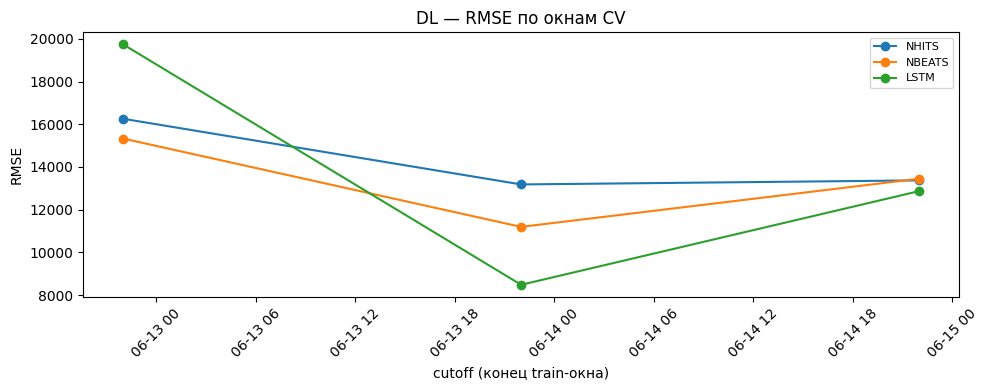

Лучшая DL-модель по backtest: NBEATS


In [20]:
dl_cv_models = [
    NHITS(h=CV_H, input_size=72, max_steps=200),
    NBEATS(h=CV_H, input_size=72, max_steps=200),
    LSTM(h=CV_H, input_size=72, max_steps=200),
]
dl_cv_names = [str(m) for m in dl_cv_models]

dlf_cv = NeuralForecast(models=dl_cv_models, freq='h')

print(f'DL cross-validation: h={CV_H}, n_windows={DL_N_WINDOWS}, step={CV_STEP}')
dl_cv = dlf_cv.cross_validation(
    df=cv_data,
    n_windows=DL_N_WINDOWS,
    step_size=CV_STEP,
    h=CV_H,
    refit=True,
)

dl_cv_overall = cv_summary(dl_cv, dl_cv_names)
display(dl_cv_overall)

dl_cv_window = cv_by_window(dl_cv, dl_cv_names)
display(dl_cv_window.pivot(index='cutoff', columns='model', values='RMSE').round(2))
plot_cv_rmse_by_window(dl_cv_window, dl_cv_names, title='DL — RMSE по окнам CV')

best_dl_cv = dl_cv_overall.index[0]
print(f'Лучшая DL-модель по backtest: {best_dl_cv}')

## Анализ остатков (ML & DL)

In-sample остатки для лучшей ML-модели по hold-out; out-of-sample остатки из CV для DL. Проверка: ACF, Q–Q, Ljung–Box.

Лучшая ML-модель на hold-out: Ridge
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000360 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1779
[LightGBM] [Info] Number of data points in the train set: 717, number of used features: 12
[LightGBM] [Info] Start training from score 33.645814
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No

,count,mean,std,min,25%,50%,75%,max
model,,,,,,,,
Ridge,717.0,0.0,9803.94,-60962.97,-1149.4,688.44,2571.87,41060.67


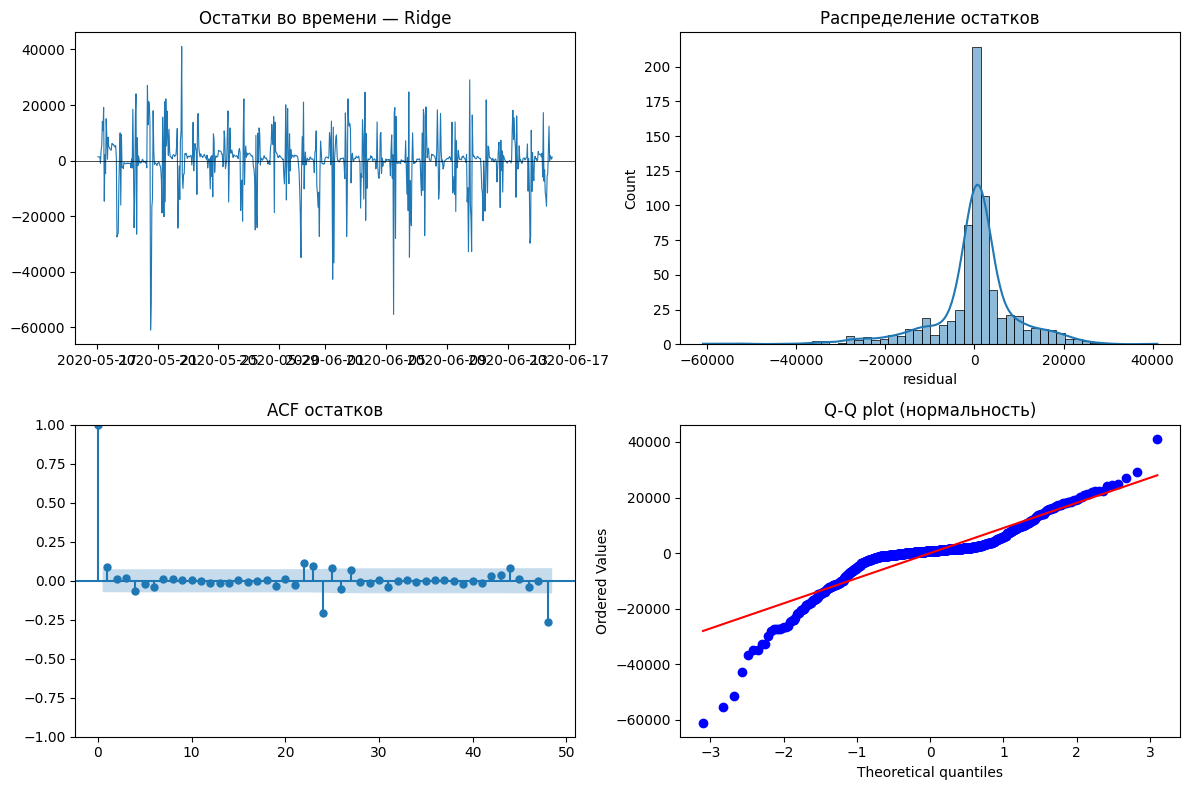

Ljung–Box (Ridge):


,lb_stat,lb_pvalue
24,61.103450,4.455054e-05
48,135.313502,3.002288e-10


In [21]:
ml_holdout = print_metrics(test_data, ml_forecasts, list(mlf.models.keys()))
best_ml_name = ml_holdout.index[0]
print(f'Лучшая ML-модель на hold-out: {best_ml_name}')

residual_data = cv_data.copy()
mlf_res = MLForecast(
    models=ml_models,
    freq='h',
    lags=[1, 2, 6, 12, 24],
    lag_transforms={1: [ExpandingMean()], 24: [RollingMean(window_size=3)]},
    date_features=['hour', 'dayofweek'],
    target_transforms=[Differences([24])],
)
mlf_res.fit(residual_data, static_features=[], fitted=True)
ml_fitted = mlf_res.forecast_fitted_values()
ml_res_df = with_residuals(ml_fitted, best_ml_name)
display(ml_res_df.groupby('model')['residual'].describe().round(2))
plot_residual_diagnostics(ml_res_df, best_ml_name)

Лучшая DL-модель на hold-out: NHITS


,count,mean,std,min,25%,50%,75%,max
model,,,,,,,,
NBEATS,72.0,2905.62,13207.31,-43024.24,-836.53,152.79,5433.03,38230.91


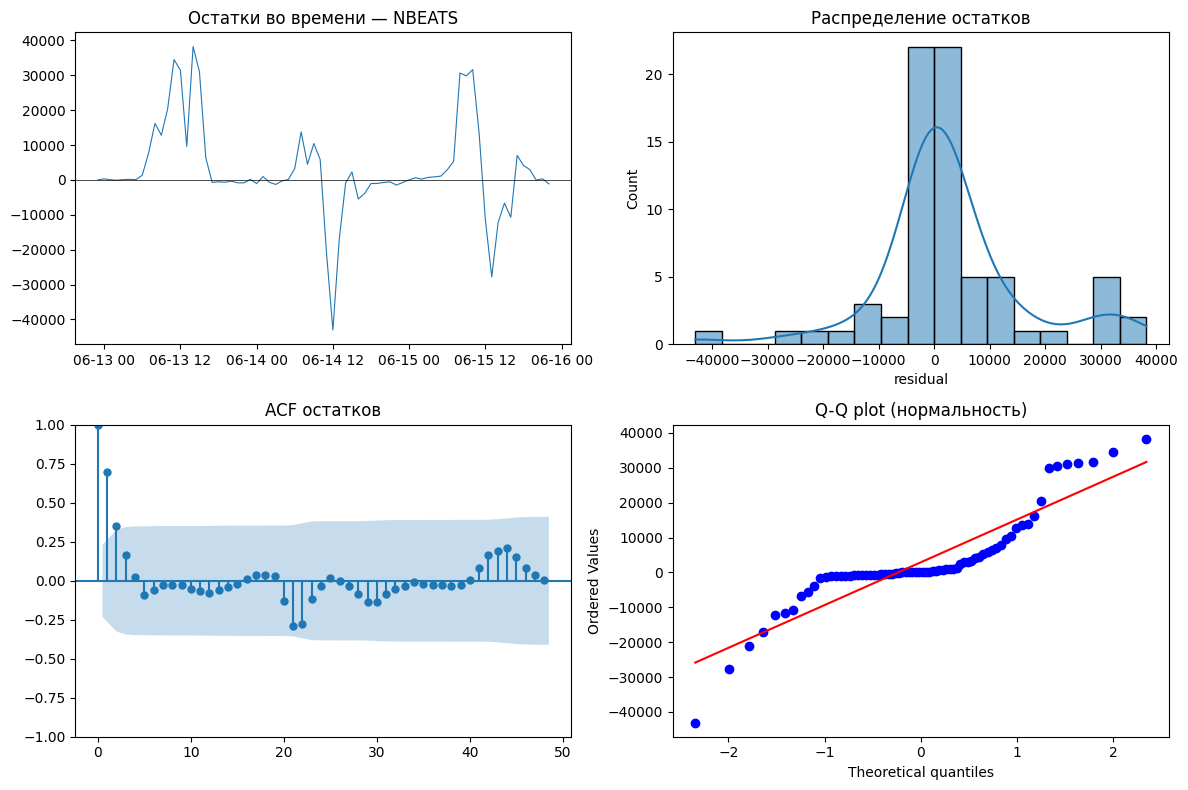

Ljung–Box (NBEATS):


,lb_stat,lb_pvalue
24,71.817809,0.000001
48,106.668203,0.000002


In [22]:
dl_holdout = print_metrics(test_data, dl_forecasts, [str(m) for m in dlf.models])
best_dl_name = dl_holdout.index[0]
print(f'Лучшая DL-модель на hold-out: {best_dl_name}')

dl_res_df = with_cv_residuals(dl_cv, best_dl_cv)
display(dl_res_df.groupby('model')['residual'].describe().round(2))
plot_residual_diagnostics(dl_res_df, best_dl_cv)